 # BESS Optimization Pipeline



 This notebook demonstrates a complete end-to-end pipeline for a Battery Energy Storage System (BESS) optimization project.

 It is designed to showcase data engineering, statistical forecasting, machine learning (with hyperparameter tuning),

 and operations research (Linear Programming) capabilities.

In [13]:
import requests
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import pulp
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')


 ## 1. Fetching Real Danish Power Market Data



 We fetch real Day-Ahead spot prices for the DK2 bidding zone (which includes Copenhagen)

 using the public API provided by Energinet, the Danish TSO.

In [14]:
def fetch_dk2_spot_prices(start_date: str, end_date: str) -> pd.DataFrame:
    """Fetches real day-ahead prices from Energinet API for DK2."""
    url = "https://api.energidataservice.dk/dataset/Elspotprices"
    
    # HourUTC is Energinet's primary index; safest to sort by this.
    params = {
        "start": start_date,
        "end": end_date,
        "filter": '{"PriceArea":"DK2"}',
        "sort": "HourUTC ASC"
    }
    
    response = requests.get(url, params=params)
    response.raise_for_status()
    
    data = response.json().get('records', [])
    
    if not data:
        raise ValueError(f"API returned 0 records for dates {start_date} to {end_date}.")
        
    df = pd.DataFrame(data)
    df['HourDK'] = pd.to_datetime(df['HourDK'])
    
    # Keep timestamp and spot price, drop NaNs
    df = df.set_index('HourDK')[['SpotPriceDKK']].sort_index().dropna()
    
    # Remove duplicate hours (can happen during Daylight Saving Time transitions)
    df = df[~df.index.duplicated(keep='first')]
    
    return df

print("Fetching Energinet data...")

# Hardcoding a guaranteed historical 90-day window
start_str = "2024-01-01"
end_str = "2024-04-01"

print(f"Requesting data from {start_str} to {end_str}...")
df_prices = fetch_dk2_spot_prices(start_str, end_str)

print(f"Fetched {len(df_prices)} hourly records successfully.")

Fetching Energinet data...
Requesting data from 2024-01-01 to 2024-04-01...
Fetched 2183 hourly records successfully.


                     SpotPriceDKK
HourDK                           
2024-01-01 00:00:00    217.160004
2024-01-01 01:00:00    212.160004
2024-01-01 02:00:00    198.740005
2024-01-01 03:00:00    182.490005
2024-01-01 04:00:00    178.990005
2024-01-01 05:00:00    118.379997
2024-01-01 06:00:00    118.309998
2024-01-01 07:00:00    164.300003
2024-01-01 08:00:00    189.500000
2024-01-01 09:00:00    240.119995
2024-01-01 10:00:00    308.179993
2024-01-01 11:00:00    324.359985
2024-01-01 12:00:00    320.700012
2024-01-01 13:00:00    330.170013
2024-01-01 14:00:00    344.709991
2024-01-01 15:00:00    377.290009
2024-01-01 16:00:00    443.329987
2024-01-01 17:00:00    484.480011
2024-01-01 18:00:00    460.260010
2024-01-01 19:00:00    410.529999


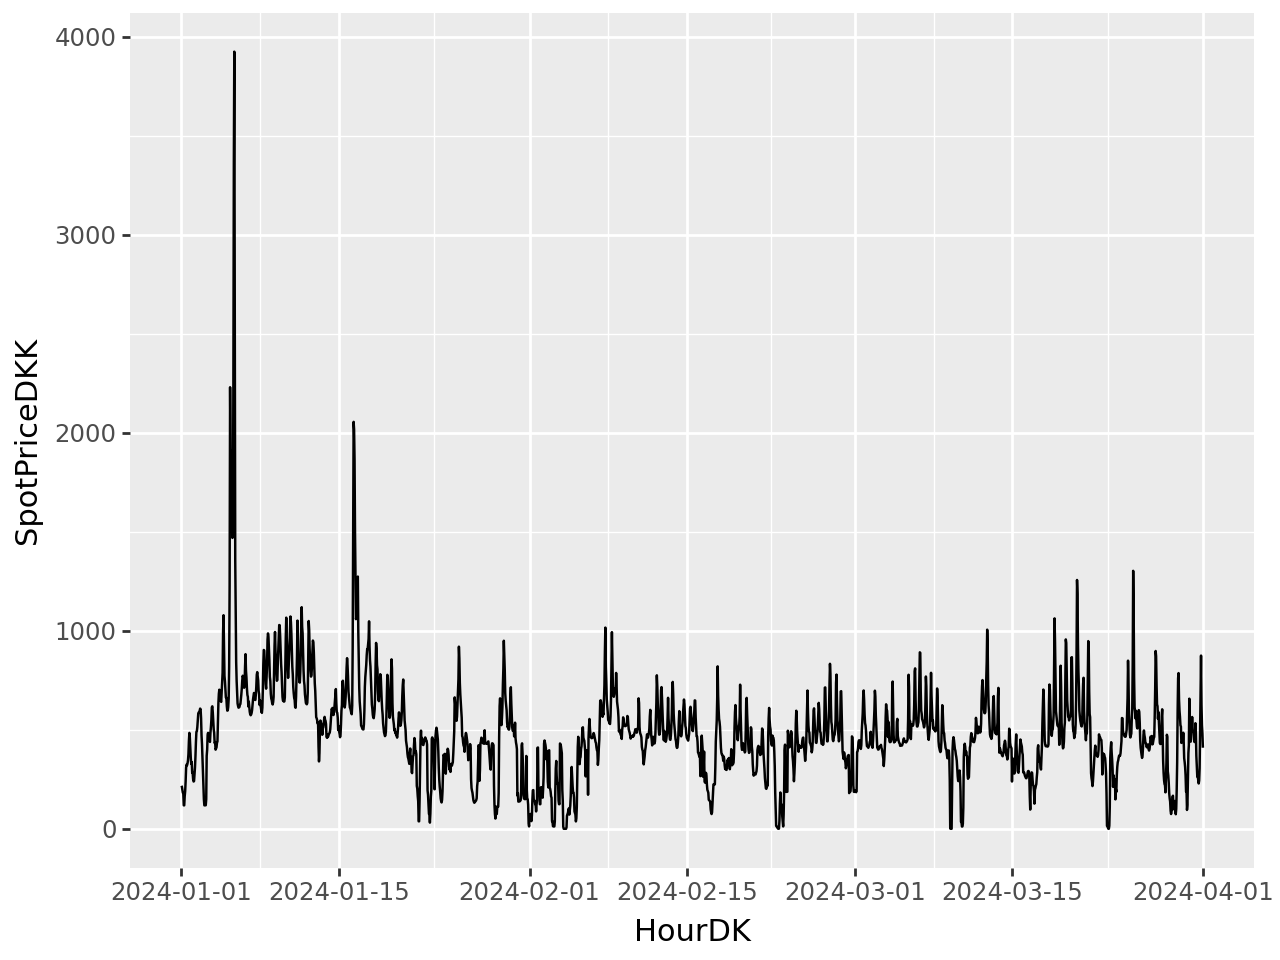

In [15]:
from plotnine import (
    ggplot, aes, geom_line, geom_col, facet_grid, 
    theme_minimal, theme, labs, element_text, geom_point
)
print(df_prices.head(20))

(
    ggplot(df_prices.reset_index(), aes(x='HourDK', y='SpotPriceDKK')) + geom_line() 
) 

 ## 2. Baseline Time Series Forecasting (ARIMA)



 Before applying complex machine learning algorithms, we establish a statistical baseline using an ARIMA model.

 The mathematical formulation for an $ARIMA(p, d, q)$ model is:

 $$\left(1 - \sum_{i=1}^p \phi_i L^i\right) (1 - L)^d y_t = \left(1 + \sum_{j=1}^q \theta_j L^j\right) \varepsilon_t$$

 Where $L$ is the lag operator, $\phi$ are autoregressive parameters, $\theta$ are moving average parameters, and $\varepsilon_t$ is white noise.

In [16]:
# Splitting the last 48 hours as our test set for the day-ahead + 1 scenario
train_series = df_prices['SpotPriceDKK'].iloc[:-48]
test_series = df_prices['SpotPriceDKK'].iloc[-48:]

print("Training ARIMA baseline...")
# Using a simple order for compilation speed; in production, this requires ACF/PACF analysis
arima_model = ARIMA(train_series, order=(2, 1, 2))
arima_fitted = arima_model.fit()

arima_preds = arima_fitted.forecast(steps=48)
arima_mae = mean_absolute_error(test_series, arima_preds)
print(f"ARIMA Baseline MAE: {arima_mae:.2f} DKK")


Training ARIMA baseline...
ARIMA Baseline MAE: 112.28 DKK


 ## 3. Advanced Forecasting (XGBoost + Optuna)



 To improve our forecast, we frame the time series problem as a supervised learning task using lag features.

 We utilize Optuna to systematically search the hyperparameter space to minimize the objective function (MAE).

In [17]:
def create_features(df, lags=24):
    """Generates lag and temporal features."""
    df_feat = df.copy()
    for i in range(1, lags + 1):
        df_feat[f'lag_{i}'] = df_feat['SpotPriceDKK'].shift(i)
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    return df_feat.dropna()

df_features = create_features(df_prices, lags=48)

# Features and target
X = df_features.drop(columns=['SpotPriceDKK'])
y = df_features['SpotPriceDKK']

# Train/Val/Test split (chronological)
X_train_val, X_test = X.iloc[:-48], X.iloc[-48:]
y_train_val, y_test = y.iloc[:-48], y.iloc[-48:]

# Split train_val into train and validation for Optuna
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, shuffle=False)

def objective(trial):
    """Optuna objective function for XGBoost tuning."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0)
    }
    
    model = xgb.XGBRegressor(**params, random_state=42, objective='reg:squarederror')
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return mean_absolute_error(y_val, preds)

print("Running Optuna optimization for XGBoost...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=15) # Kept low for execution speed

# Train final model on best params
best_params = study.best_params
print(f"Best XGBoost Params: {best_params}")

final_xgb = xgb.XGBRegressor(**best_params, random_state=42, objective='reg:squarederror')
final_xgb.fit(X_train_val, y_train_val)

xgb_preds = final_xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_preds)
print(f"XGBoost MAE: {xgb_mae:.2f} DKK")


Running Optuna optimization for XGBoost...
Best XGBoost Params: {'n_estimators': 85, 'max_depth': 5, 'learning_rate': 0.07039203521543032, 'subsample': 0.8792425018993902}
XGBoost MAE: 56.73 DKK


 ## 4. BESS Optimization via Linear Programming (LP)



 Using our forecasted prices, we construct an LP to dictate the optimal dispatch schedule.



 **Objective Function (Maximize Profit):**

 $$\max \sum_{t=1}^{T} p_t \cdot (D_t - C_t) \cdot \Delta t$$

 Where $p_t$ is the price, $D_t$ is discharge power, $C_t$ is charge power.



 **Subject to Constraints:**

 1. State of Charge (SoC) Transition:

 $$SoC_t = SoC_{t-1} + \left( C_t \cdot \eta_c - \frac{D_t}{\eta_d} \right) \cdot \Delta t$$

 2. Power and Energy Limits:

 $$0 \leq C_t \leq P_{max}, \quad 0 \leq D_t \leq P_{max}, \quad E_{min} \leq SoC_t \leq E_{max}$$

In [18]:
def optimize_battery_dispatch(prices: np.ndarray, P_max=10, E_max=20, eta=0.95):
    """
    Formulates and solves the BESS linear program using PuLP.
    P_max: MW (Power capacity)
    E_max: MWh (Energy capacity)
    eta: Round-trip efficiency (assumed symmetric)
    """
    T = len(prices)
    prob = pulp.LpProblem("BESS_Dispatch", pulp.LpMaximize)
    
    # Decision Variables
    C = pulp.LpVariable.dicts("Charge", range(T), lowBound=0, upBound=P_max)
    D = pulp.LpVariable.dicts("Discharge", range(T), lowBound=0, upBound=P_max)
    SoC = pulp.LpVariable.dicts("SoC", range(T), lowBound=0, upBound=E_max)
    
    # Objective: Maximize Arbitrage Profit
    # Profit = Revenue from discharging - Cost of charging
    prob += pulp.lpSum([prices[t] * (D[t] - C[t]) for t in range(T)])
    
    # Constraints
    for t in range(T):
        if t == 0:
            # Assume battery starts empty
            prob += SoC[t] == C[t] * eta - (D[t] / eta)
        else:
            # Transition state
            prob += SoC[t] == SoC[t-1] + C[t] * eta - (D[t] / eta)
            
    # Solve
    solver = pulp.PULP_CBC_CMD(msg=False)
    prob.solve(solver)
    
    # Results formatting
    profit = pulp.value(prob.objective)
    schedule = pd.DataFrame({
        'Forecasted_Price': prices,
        'Charge_MW': [C[t].varValue for t in range(T)],
        'Discharge_MW': [D[t].varValue for t in range(T)],
        'SoC_MWh': [SoC[t].varValue for t in range(T)]
    })
    
    return profit, schedule

print("Running BESS Optimization using XGBoost predictions...")
# Use the XGBoost predictions (last 48 hours) for the optimization
forecasted_prices = xgb_preds
optimal_profit, dispatch_schedule = optimize_battery_dispatch(forecasted_prices)

print(f"\nExpected Optimal Profit for 48h window: {optimal_profit:.2f} DKK")
print("\nFirst 5 hours of Dispatch Schedule:")
print(dispatch_schedule.head())

Running BESS Optimization using XGBoost predictions...

Expected Optimal Profit for 48h window: 20729.43 DKK

First 5 hours of Dispatch Schedule:
   Forecasted_Price  Charge_MW  Discharge_MW    SoC_MWh
0        542.063477   0.000000           0.0   0.000000
1        509.041809   0.000000           0.0   0.000000
2        511.682861   0.000000           0.0   0.000000
3        432.767914  10.000000           0.0   9.500000
4        436.813812   1.080332           0.0  10.526316


In [19]:
# %% [markdown]
# ## 5. BESS Optimization Comparison & Visualization
# 
# We now pass both the ARIMA predictions and the XGBoost predictions through our 
# Linear Programming optimizer to compare the dispatch schedules. Finally, we use 
# `plotnine` to visualize the results side-by-side.

# %%
import pandas as pd
import pulp
from plotnine import (
    ggplot, aes, geom_line, geom_col, facet_grid, 
    theme_minimal, theme, labs, element_text
)

# 1. Define the Optimization Function
def optimize_battery_dispatch(prices, P_max=10, E_max=20, eta=0.95):
    """Solves the BESS linear program for a given array of prices."""
    price_array = prices.values if isinstance(prices, pd.Series) else prices
    T = len(price_array)
    
    prob = pulp.LpProblem("BESS_Dispatch", pulp.LpMaximize)
    
    C = pulp.LpVariable.dicts("Charge", range(T), lowBound=0, upBound=P_max)
    D = pulp.LpVariable.dicts("Discharge", range(T), lowBound=0, upBound=P_max)
    SoC = pulp.LpVariable.dicts("SoC", range(T), lowBound=0, upBound=E_max)
    
    prob += pulp.lpSum([price_array[t] * (D[t] - C[t]) for t in range(T)])
    
    for t in range(T):
        if t == 0:
            prob += SoC[t] == C[t] * eta - (D[t] / eta)
        else:
            prob += SoC[t] == SoC[t-1] + C[t] * eta - (D[t] / eta)
            
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    
    profit = pulp.value(prob.objective)
    schedule = pd.DataFrame({
        'Price': price_array,
        'Charge': [C[t].varValue for t in range(T)],
        'Discharge': [D[t].varValue for t in range(T)],
        'SoC': [SoC[t].varValue for t in range(T)]
    })
    return profit, schedule

print("Running Optimizations for both models...")

# 2. Execute Optimizations
arima_profit, arima_schedule = optimize_battery_dispatch(arima_preds)
xgb_profit, xgb_schedule = optimize_battery_dispatch(xgb_preds)

print(f"ARIMA Forecasted Profit:   {arima_profit:.2f} DKK")
print(f"XGBoost Forecasted Profit: {xgb_profit:.2f} DKK")

# 3. Prepare Tidy Data for Plotnine
arima_df = arima_schedule.copy()
arima_df['Model'] = 'ARIMA'
arima_df['Hour'] = range(len(arima_df))

xgb_df = xgb_schedule.copy()
xgb_df['Model'] = 'XGBoost'
xgb_df['Hour'] = range(len(xgb_df))

df_combined = pd.concat([arima_df, xgb_df])
df_combined['Net Power (MW)'] = df_combined['Charge'] - df_combined['Discharge']
df_plot = df_combined.rename(columns={'Price': 'Price (DKK)', 'SoC': 'SoC (MWh)'})

df_melt = df_plot.melt(
    id_vars=['Hour', 'Model'], 
    value_vars=['Price (DKK)', 'SoC (MWh)', 'Net Power (MW)'],
    var_name='Metric', 
    value_name='Value'
)

df_melt['Metric'] = pd.Categorical(
    df_melt['Metric'], 
    categories=['Price (DKK)', 'SoC (MWh)', 'Net Power (MW)'], 
    ordered=True
)

# 4. Generate Plot
print("Generating Plotnine visualization...")

dispatch_plot = (
    ggplot(df_melt, aes(x='Hour', y='Value', fill='Metric', color='Metric'))
    + geom_line(data=df_melt[df_melt['Metric'] != 'Net Power (MW)'], size=1)
    + geom_col(data=df_melt[df_melt['Metric'] == 'Net Power (MW)'], alpha=0.8, color='none')
    + facet_grid('Metric ~ Model', scales='free_y')
    + theme_minimal()
    + theme(
        figure_size=(14, 8), 
        legend_position='none',
        strip_text_y=element_text(angle=0, ha='left'),
        strip_text_x=element_text(size=12, weight='bold')
    )
    + labs(
        title='BESS Dispatch Optimization: ARIMA vs XGBoost Forecasts', 
        x='Hour (Lookahead)', 
        y=''
    )
)

print(dispatch_plot)

Running Optimizations for both models...
ARIMA Forecasted Profit:   0.00 DKK
XGBoost Forecasted Profit: 20729.43 DKK
Generating Plotnine visualization...
<ggplot: (1400 x 800)>


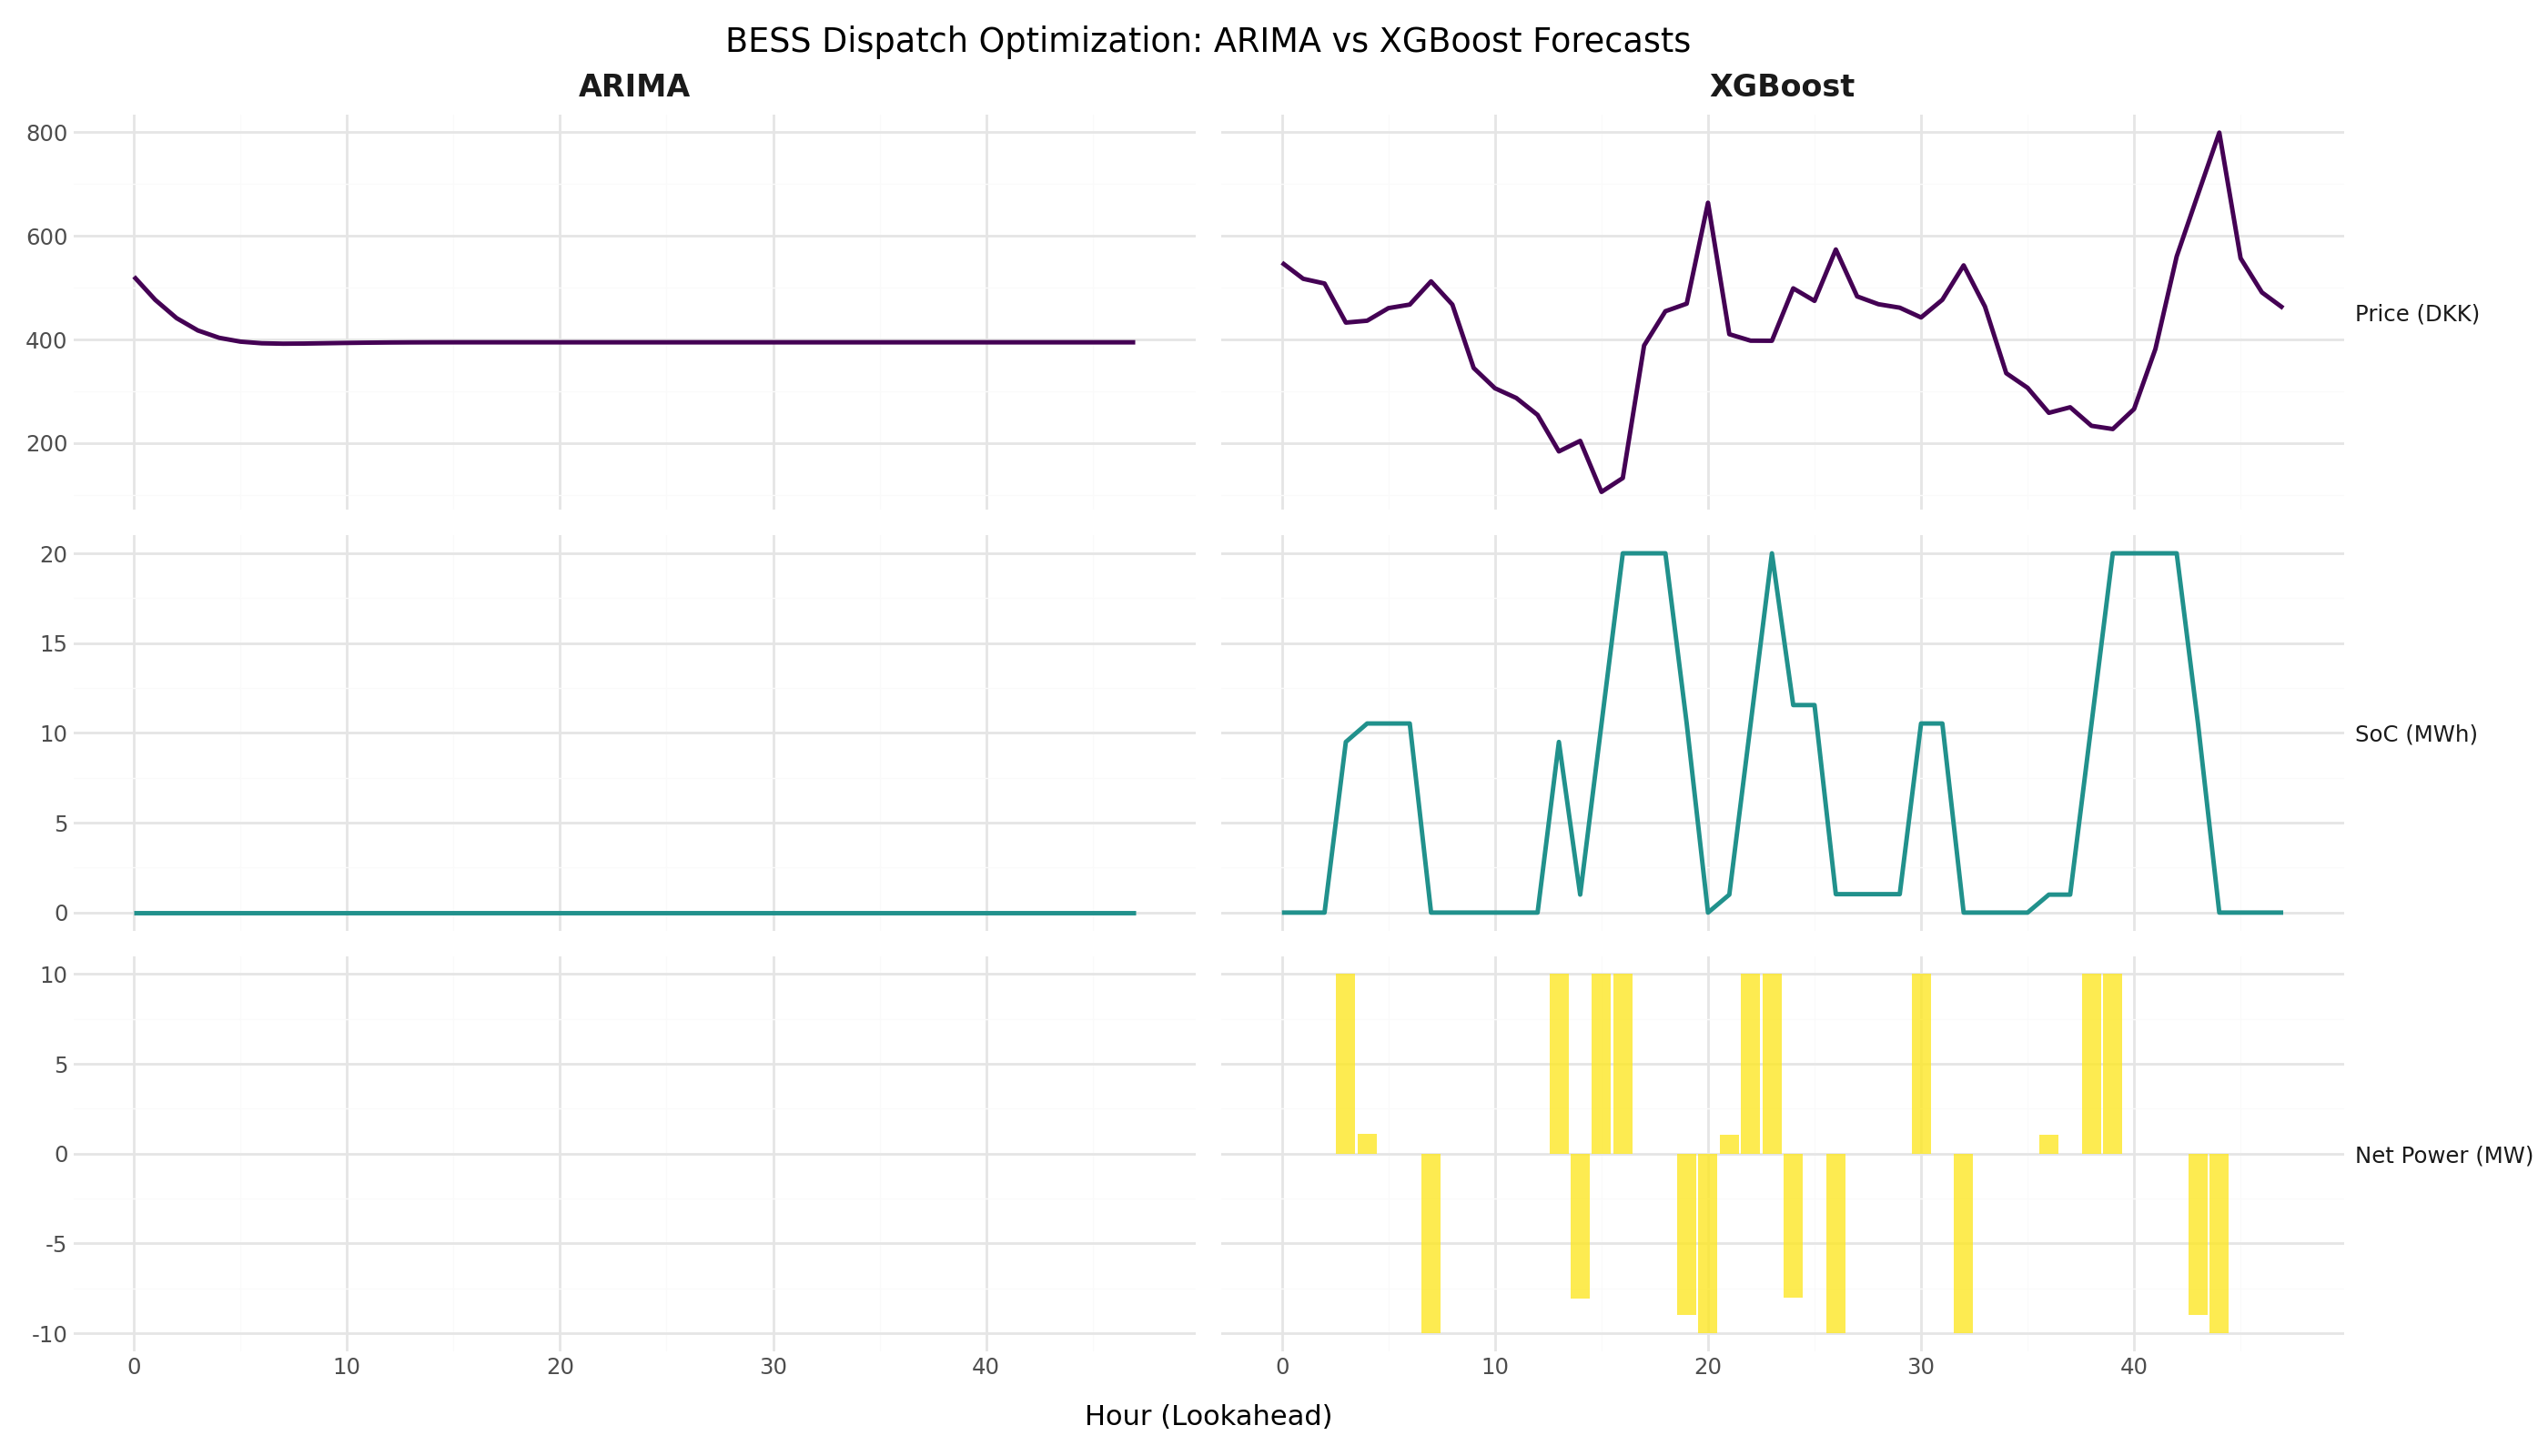

In [22]:
dispatch_plot